
NOTEBOOK 1: Exploratory Data Analysis
Bridge Digital Twin Dataset

This notebook covers:
- Data loading and basic statistics
- Missing values analysis
- Feature distributions
- Correlation analysis
- Time series patterns
- Health index evolution

Saved outputs:
- data/processed/eda_summary.csv
- outputs/eda_*.png


In [1]:
# Import data exploration Liberaries:

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_data, print_section
from src.config import *

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(COLOR_PALETTE)


In [2]:
# 1. LOAD DATA:
# ===================================================

print_section("Loading Data")


  Loading Data


In [4]:
# Load dataset

bridge_df = load_data(os.path.join(RAW_DATA_DIR, 'bridge_digital_twin_dataset.csv'))

print(f"Dataset shape:{bridge_df.shape}")
print(f"Time range: {bridge_df['Timestamp'].min()} to {bridge_df['Timestamp'].max()}")
print(f"Duration: {(bridge_df['Timestamp'].max() - bridge_df['Timestamp'].min())}")
print(f"\nColumns : {bridge_df.columns.tolist()}")

Dataset shape:(43200, 54)
Time range: 2023-01-01 00:00:00 to 2023-01-30 23:59:00
Duration: 29 days 23:59:00

Columns : ['Timestamp', 'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2', 'Tilt_deg', 'Displacement_mm', 'Crack_Propagation_mm', 'Corrosion_Level_percent', 'Cable_Member_Tension_kN', 'Bearing_Joint_Forces_kN', 'Fatigue_Accumulation_au', 'Modal_Frequency_Hz', 'Temperature_C', 'Humidity_percent', 'Wind_Speed_ms', 'Wind_Direction_deg', 'Precipitation_mmh', 'Water_Level_m', 'Seismic_Activity_ms2', 'Solar_Radiation_Wm2', 'Air_Quality_Index_AQI', 'Soil_Settlement_mm', 'Vehicle_Load_tons', 'Traffic_Volume_vph', 'Pedestrian_Load_pph', 'Impact_Events_g', 'Dynamic_Load_Distribution_percent', 'Axle_Counts_pmin', 'Structural_Health_Index_SHI', 'Anomaly_Detection_Score', 'Energy_Dissipation_au', 'Acoustic_Emissions_levels', 'Visual_Analysis_Defect_Score', 'Electrical_Resistance_ohms', 'Bridge_Mood_Meter', 'Localized_Strain_Hotspot', 'Vibration_Anomaly_Location', 'SHI_Predicted_24h_Ahea

In [5]:
# ============================================
# 2. BASIC STATISTICS
# ============================================
print_section("Basic Statistics")


  Basic Statistics


In [7]:
bridge_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,43200,2023-01-15 23:59:30,2023-01-01 00:00:00,2023-01-08 11:59:45,2023-01-15 23:59:30,2023-01-23 11:59:15,2023-01-30 23:59:00,NaN
Strain_microstrain,41379.0,851.950836,363.529753,618.866446,734.476653,1072.66168,4074.893156,351.90831
Deflection_mm,41467.0,15.145403,6.889697,12.447132,14.98616,17.090508,30.38908,3.824032
Vibration_ms2,41478.0,1.339495,0.637735,1.00003,1.198123,1.532924,15.08648,0.979641
Tilt_deg,41447.0,0.756122,0.476074,0.667321,0.724295,0.832503,1.522738,0.142167
Displacement_mm,41473.0,22.703596,18.964441,21.387484,22.361439,23.985103,27.630262,1.627841
Crack_Propagation_mm,41494.0,0.015036,-0.001531,0.007511,0.015024,0.022526,0.519706,0.009338
Corrosion_Level_percent,41531.0,0.14995,-0.010256,0.074979,0.150101,0.224839,0.312679,0.086731
Cable_Member_Tension_kN,41459.0,476.054924,334.045442,396.924817,447.899673,556.36281,844.862138,91.773467
Bearing_Joint_Forces_kN,41515.0,276.967988,205.758025,237.447819,260.075977,318.127839,423.909686,45.59084


In [8]:
# Save summary statistics
bridge_df.describe().T.to_csv(os.path.join(PROCESSED_DATA_DIR, 'eda_summary.csv'))
print(f"\n✓ Saved: data/processed/eda_summary.csv")


✓ Saved: data/processed/eda_summary.csv


In [9]:
# ============================================
# 3. MISSING VALUES
# ============================================
print_section("Missing Values Analysis")


  Missing Values Analysis


In [10]:
missing = bridge_df.isnull().sum()
missing_pct = (missing / len(bridge_df)) * 100

missing_df = pd.DataFrame({
    'Missing_count': missing,
    'Missing_percentage':missing_pct
}).sort_values('Missing_count',ascending=False)

print(missing_df[missing_df['Missing_count'] > 0])

                                       Missing_count  Missing_percentage
Vibration_Anomaly_Location                     34155           79.062500
Strain_microstrain                              1821            4.215278
Humidity_percent                                1783            4.127315
Estimated_Repair_Cost_USD_incremental           1771            4.099537
Wind_Direction_deg                              1768            4.092593
Landslide_Ground_Movement                       1765            4.085648
Abnormal_Traffic_Load_Surges                    1763            4.081019
High_Winds_Storms                               1758            4.069444
Vehicle_Load_tons                               1756            4.064815
Localized_Strain_Hotspot                        1754            4.060185
Tilt_deg                                        1753            4.057870
Soil_Saturation_percent                         1747            4.043981
Electrical_Resistance_ohms                      174

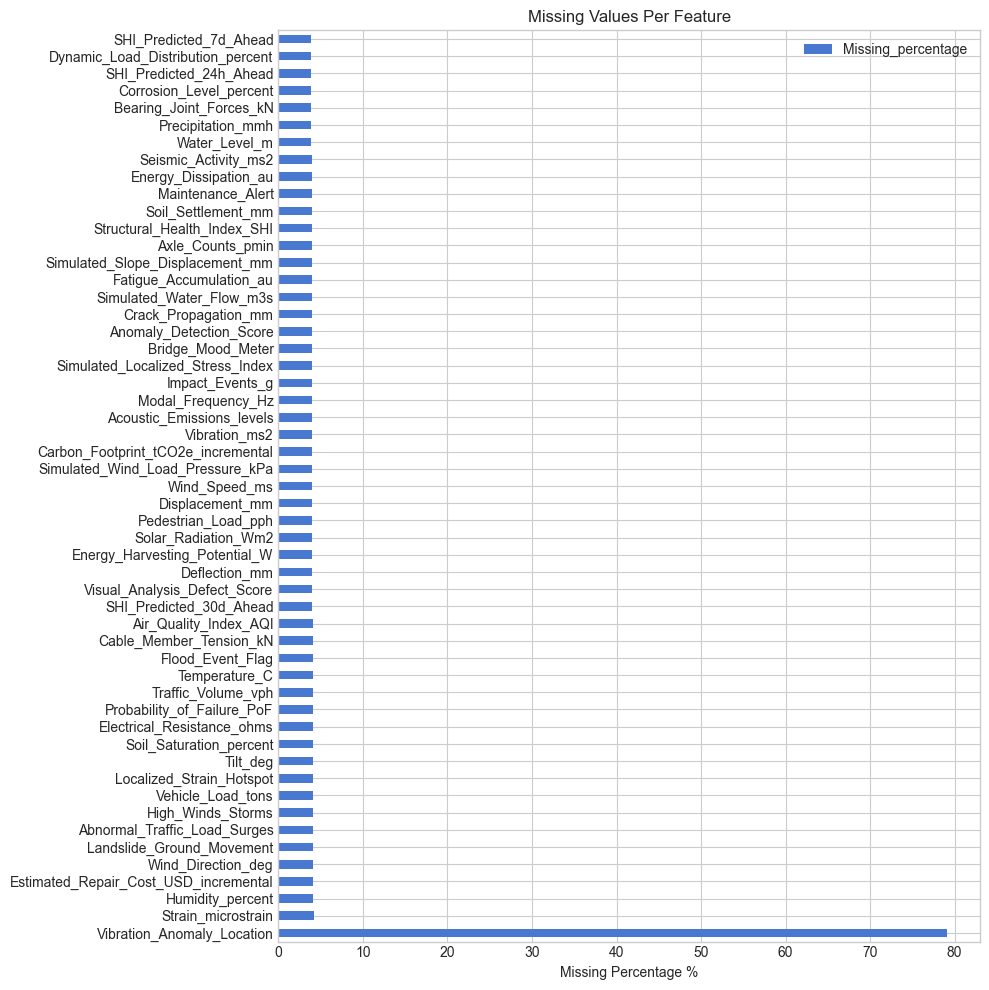

In [ ]:
fig , ax = plt.subplots(figsize = (10,10))

missing_df[missing_df['Missing_count'] > 0].plot(
    kind = 'barh',
    y = 'Missing_percentage',
    ax = ax,
    color = sns.color_palette("colorblind", n_colors=len(missing_df[missing_df['Missing_count'] > 0]))
)

plt.xlabel('Missing Percentage %')
plt.title('Missing Values Per Feature')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'eda_missing_values.png'), dpi=FIGURE_DPI)
plt.show()